<div style='background: linear-gradient(135deg, #0f0f23 0%, #1a1a2e 50%, #16213e 100%); padding: 30px; border-radius: 15px; border-left: 5px solid #e94560; text-align: center;'>
<h1 style='color: #ffffff; font-size: 32px; margin: 0;'>🎬 NETFLIX COMPETITIVE ANALYSIS</h1>
<h2 style='color: #e94560; font-size: 20px; margin: 10px 0 0 0;'>Phân tích chiến lược dưới góc nhìn đối thủ cạnh tranh</h2>
<p style='color: #a0a0a0; font-size: 13px; margin-top: 15px;'>Dữ liệu: Netflix Titles Dataset (Kaggle) • 8,806 titles • Movie (6,130) & TV Show (2,676)</p>
</div>

In [1]:
%matplotlib inline
import ast
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BG = '#0f0f23'
BG2 = '#1a1a2e'
ACCENT = '#e94560'
GOLD = '#ffd369'
GREEN = '#16c79a'
PURPLE = '#533483'
CYAN = '#00bcd4'
GRAY = '#4a4a6a'

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': BG2,
    'axes.edgecolor': ACCENT,
    'axes.labelcolor': '#e0e0e0',
    'axes.titlecolor': '#ffffff',
    'text.color': '#e0e0e0',
    'xtick.color': '#a0a0a0',
    'ytick.color': '#a0a0a0',
    'grid.color': '#2a2a4a',
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 15,
    'figure.dpi': 130,
})

df = pd.read_csv('netflix_titles_cleaned.csv')
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['added_month'] = df['date_added'].dt.month
df['added_year'] = df['date_added'].dt.year

def parse_list(col):
    result = []
    for v in df[col]:
        try:
            if isinstance(v, str) and v.startswith('['):
                items = ast.literal_eval(v)
                result.append([i.strip() for i in items if i.strip()])
            else:
                result.append([])
        except (ValueError, SyntaxError):
            result.append([])
    return result

df['genres'] = parse_list('listed_in_list')
df['countries'] = parse_list('country_list')

print('Data loaded successfully!')
print(f'Total: {len(df)} titles | Movies: {len(df[df["type"]=="Movie"])} | TV Shows: {len(df[df["type"]=="TV Show"])}')
print(f'Years: {df["release_year"].min()} - {df["release_year"].max()}')



Data loaded successfully!
Total: 8806 titles | Movies: 6130 | TV Shows: 2676
Years: 1925 - 2021


---
## 📊 CHART 1: CƠ CẤU NỘI DUNG — Movie vs TV Show

**Mục tiêu:** Hiểu Netflix đang đầu tư chủ yếu vào loại hình nội dung nào.

**Góc nhìn đối thủ:** Nếu Netflix tập trung 70% vào Movie, đối thủ có thể tấn công bằng TV Show hoặc ngược lại.

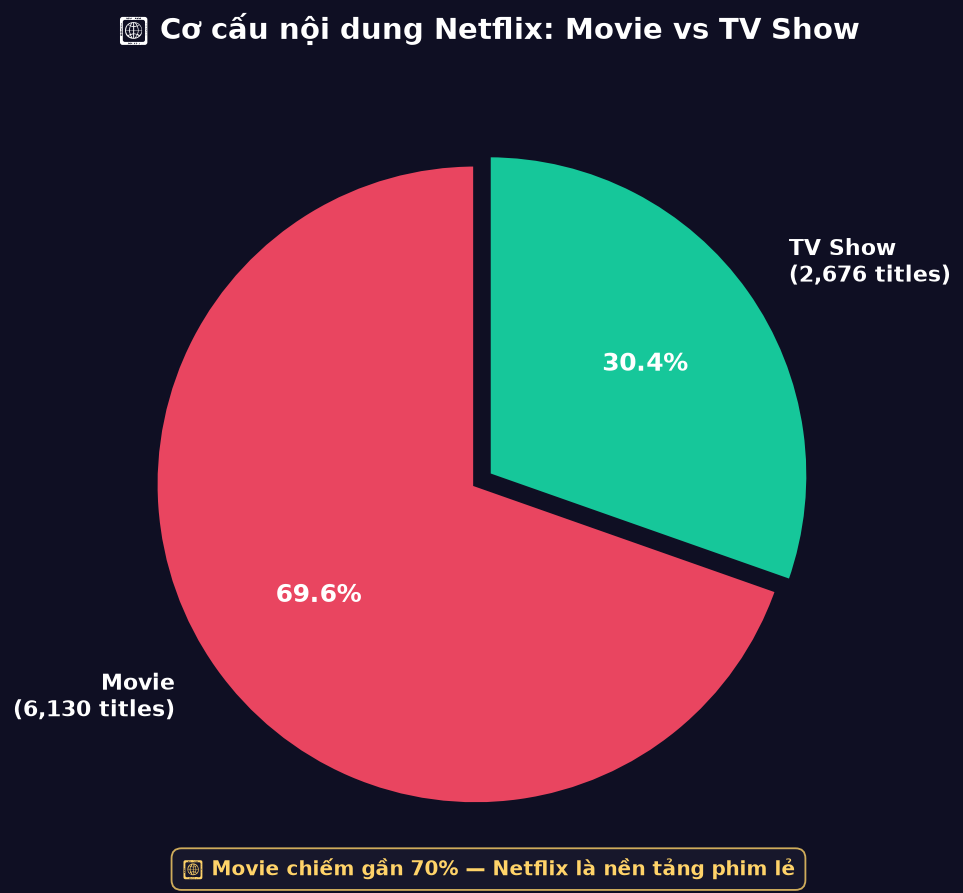

In [2]:
fig, ax = plt.subplots(figsize=(9, 7))
type_counts = df['type'].value_counts()
labels = [f'{t}\n({c:,} titles)' for t, c in type_counts.items()]
sizes = type_counts.values
explode = (0.05, 0)

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct=lambda p: f'{p:.1f}%',
    startangle=90, colors=[ACCENT, GREEN], explode=explode,
    wedgeprops={'linewidth': 2.5, 'edgecolor': BG},
    textprops={'color': 'white', 'fontsize': 12, 'fontweight': 'bold'},
    pctdistance=0.6, labeldistance=1.15
)
for at in autotexts:
    at.set_fontsize(14)
    at.set_fontweight('bold')
    at.set_color('white')

ax.set_title('\U0001f3ac C\u01a1 c\u1ea5u n\u1ed9i dung Netflix: Movie vs TV Show', fontsize=16, fontweight='bold', pad=20)
ax.text(0, -1.25, '\U0001f4a1 Movie chi\u1ebfm g\u1ea7n 70% \u2014 Netflix l\u00e0 n\u1ec1n t\u1ea3ng phim l\u1ebb',
       ha='center', fontsize=11, color=GOLD, fontweight='bold',
       bbox=dict(boxstyle='round,pad=0.5', facecolor=BG2, edgecolor=GOLD, alpha=0.8))
plt.tight_layout()
plt.show()



### 🔍 Phân tích chiến lược:

| Chỉ số | Giá trị | Ý nghĩa |
|--------|--------|---------|
| **Movie** | **6,130 (69.6%)** | Netflix là kho phim khổng lồ |
| **TV Show** | **2,676 (30.4%)** | TV Show chỉ ~1/3 tổng số |

**🎯 Chiến thuật cho đối thủ:**
- Nếu bạn là **Disney+**: nhắm vào TV Show gia đình {DASH} Netflix đang thiếu
- Nếu bạn là **HBO Max**: đánh vào series chất lượng cao
- Nếu bạn là **Amazon Prime**: tận dụng lợi thế movie gốc

---
## 📈 CHART 2: XU HƯỚNG TĂNG TRƯỞNG Movie vs TV Show

**Mục tiêu:** Theo dõi sự thay đổi chiến lược nội dung của Netflix qua các năm.

**Góc nhìn đối thủ:** Phát hiện xu hướng để đón đầu hoặc khai thác điểm yếu.

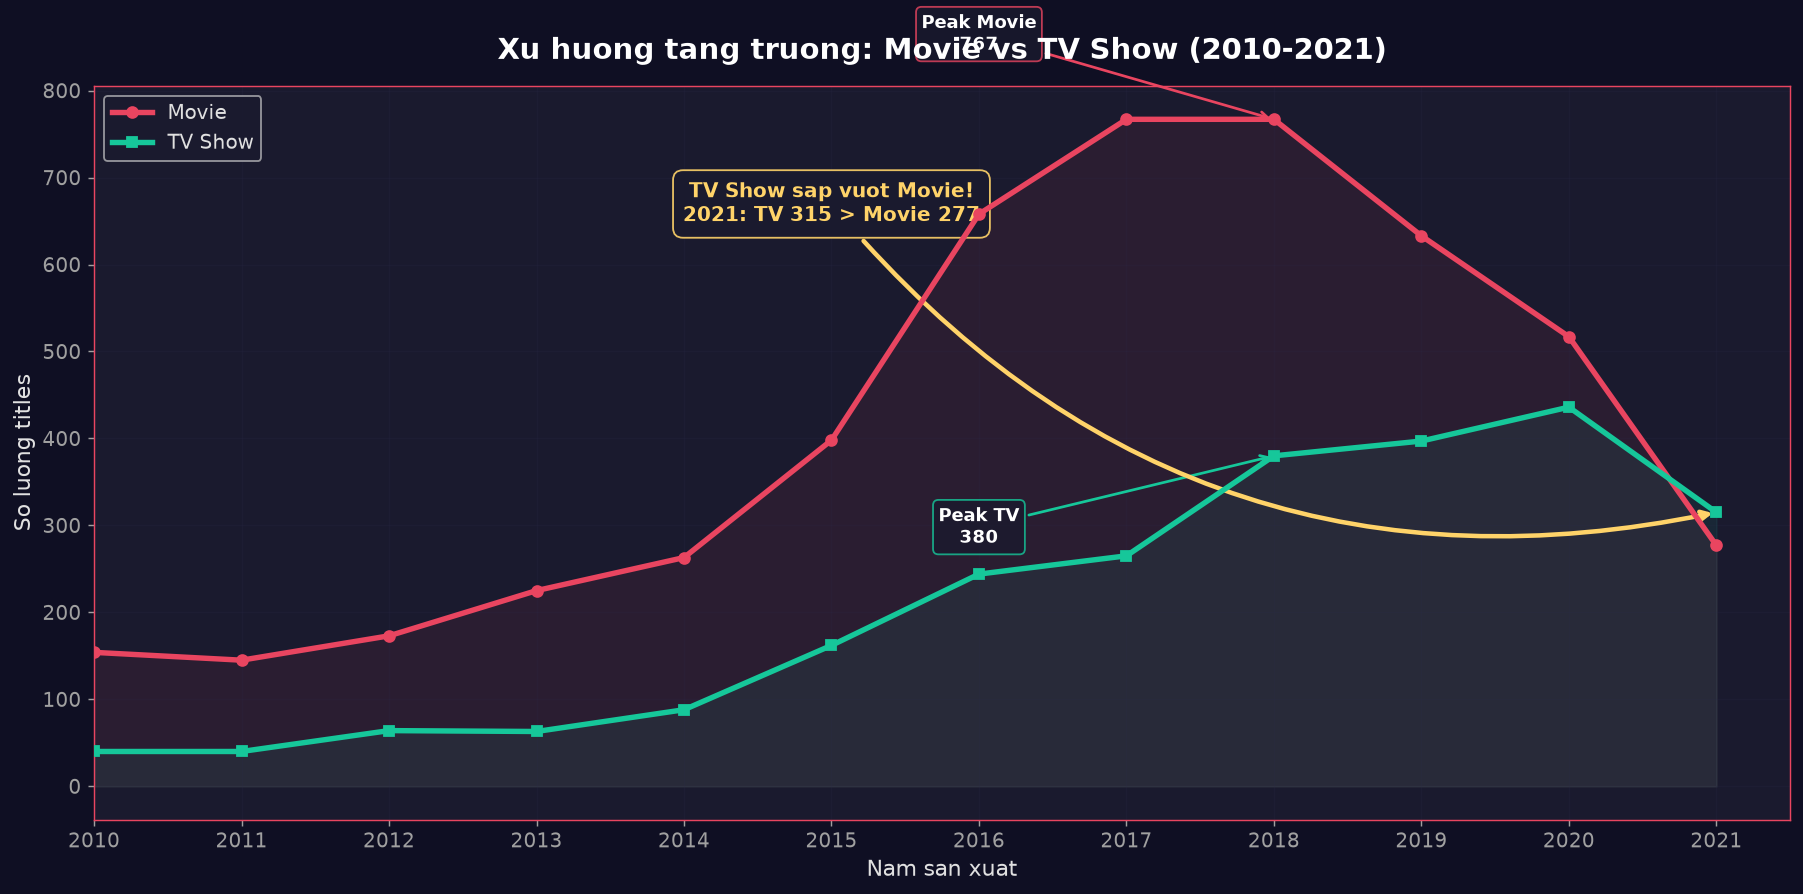

In [3]:
fig, ax = plt.subplots(figsize=(14, 7))
type_yearly = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)
type_yearly = type_yearly[type_yearly.index >= 2010]
years = type_yearly.index

ax.plot(years, type_yearly['Movie'], color=ACCENT, linewidth=3,
        marker='o', markersize=6, label='Movie', zorder=5)
ax.plot(years, type_yearly['TV Show'], color=GREEN, linewidth=3,
        marker='s', markersize=6, label='TV Show', zorder=5)
ax.fill_between(years, type_yearly['Movie'], alpha=0.08, color=ACCENT)
ax.fill_between(years, type_yearly['TV Show'], alpha=0.08, color=GREEN)

ax.annotate(f"Peak Movie\n{int(type_yearly.loc[2018, 'Movie'])}",
            xy=(2018, type_yearly.loc[2018, 'Movie']), xytext=(2016, type_yearly.loc[2018, 'Movie']+80),
            fontsize=10, color='white', fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=ACCENT, lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', facecolor=BG2, edgecolor=ACCENT, alpha=0.8))

ax.annotate(f"Peak TV\n{int(type_yearly.loc[2018, 'TV Show'])}",
            xy=(2018, type_yearly.loc[2018, 'TV Show']), xytext=(2016, type_yearly.loc[2018, 'TV Show']-100),
            fontsize=10, color='white', fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', facecolor=BG2, edgecolor=GREEN, alpha=0.8))

crossover_text = f'TV Show sap vuot Movie!\n2021: TV {type_yearly.loc[2021, "TV Show"]:.0f} > Movie {type_yearly.loc[2021, "Movie"]:.0f}'
ax.annotate(crossover_text,
    xy=(2021, type_yearly.loc[2021, 'TV Show']),
    xytext=(2015, 650),
    fontsize=11, color=GOLD, fontweight='bold', ha='center',
    arrowprops=dict(arrowstyle='->', color=GOLD, lw=2.5, connectionstyle='arc3,rad=0.3'),
    bbox=dict(boxstyle='round,pad=0.5', facecolor=BG2, edgecolor=GOLD, alpha=0.9))

ax.set_xlabel('Nam san xuat', fontsize=12)
ax.set_ylabel('So luong titles', fontsize=12)
ax.set_title('Xu huong tang truong: Movie vs TV Show (2010-2021)', fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper left', framealpha=0.7, facecolor=BG2)
ax.set_xlim(2010, 2021.5)
ax.set_xticks(range(2010, 2022))
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()



### 🔍 Phân tích chiến lược:

**Xu hướng chính:**
- **Movie** tăng trưởng nóng từ 2013 tới 2018 (đạt đỉnh 767), sau đó **giảm dần**
- **TV Show** tăng trưởng **liên tục và ổn định**: 40 (2010) tới 436 (2020)
- **2021: Lần đầu tiên TV Show > Movie** (315 vs 277) {DASH} chỉ trong nửa năm!

**🎯 Chiến thuật cho đối thủ:**
1. Netflix đang **dịch chuyển từ Movie sang TV Show** {DASH} đối thủ có thể đánh vào mảng Movie chất lượng
2. Sự sụt giảm từ 2018 (1,147) tới 2021 (592) cho thấy Netflix đang **thắt lưng buộc bụng** {DASH} thời điểm tốt để đối thủ tấn công
3. TV Show là tương lai {DASH} đầu tư vào series độc quyền chất lượng cao

---
## 🎭 CHART 3: XU HƯỚNG PHÂN LOẠI ĐỘ TUỔI (RATING)

**Mục tiêu:** Phân tích đối tượng khán giả mục tiêu của Netflix.

**Góc nhìn đối thủ:** Netflix đang bỏ ngỏ thị trường nào?

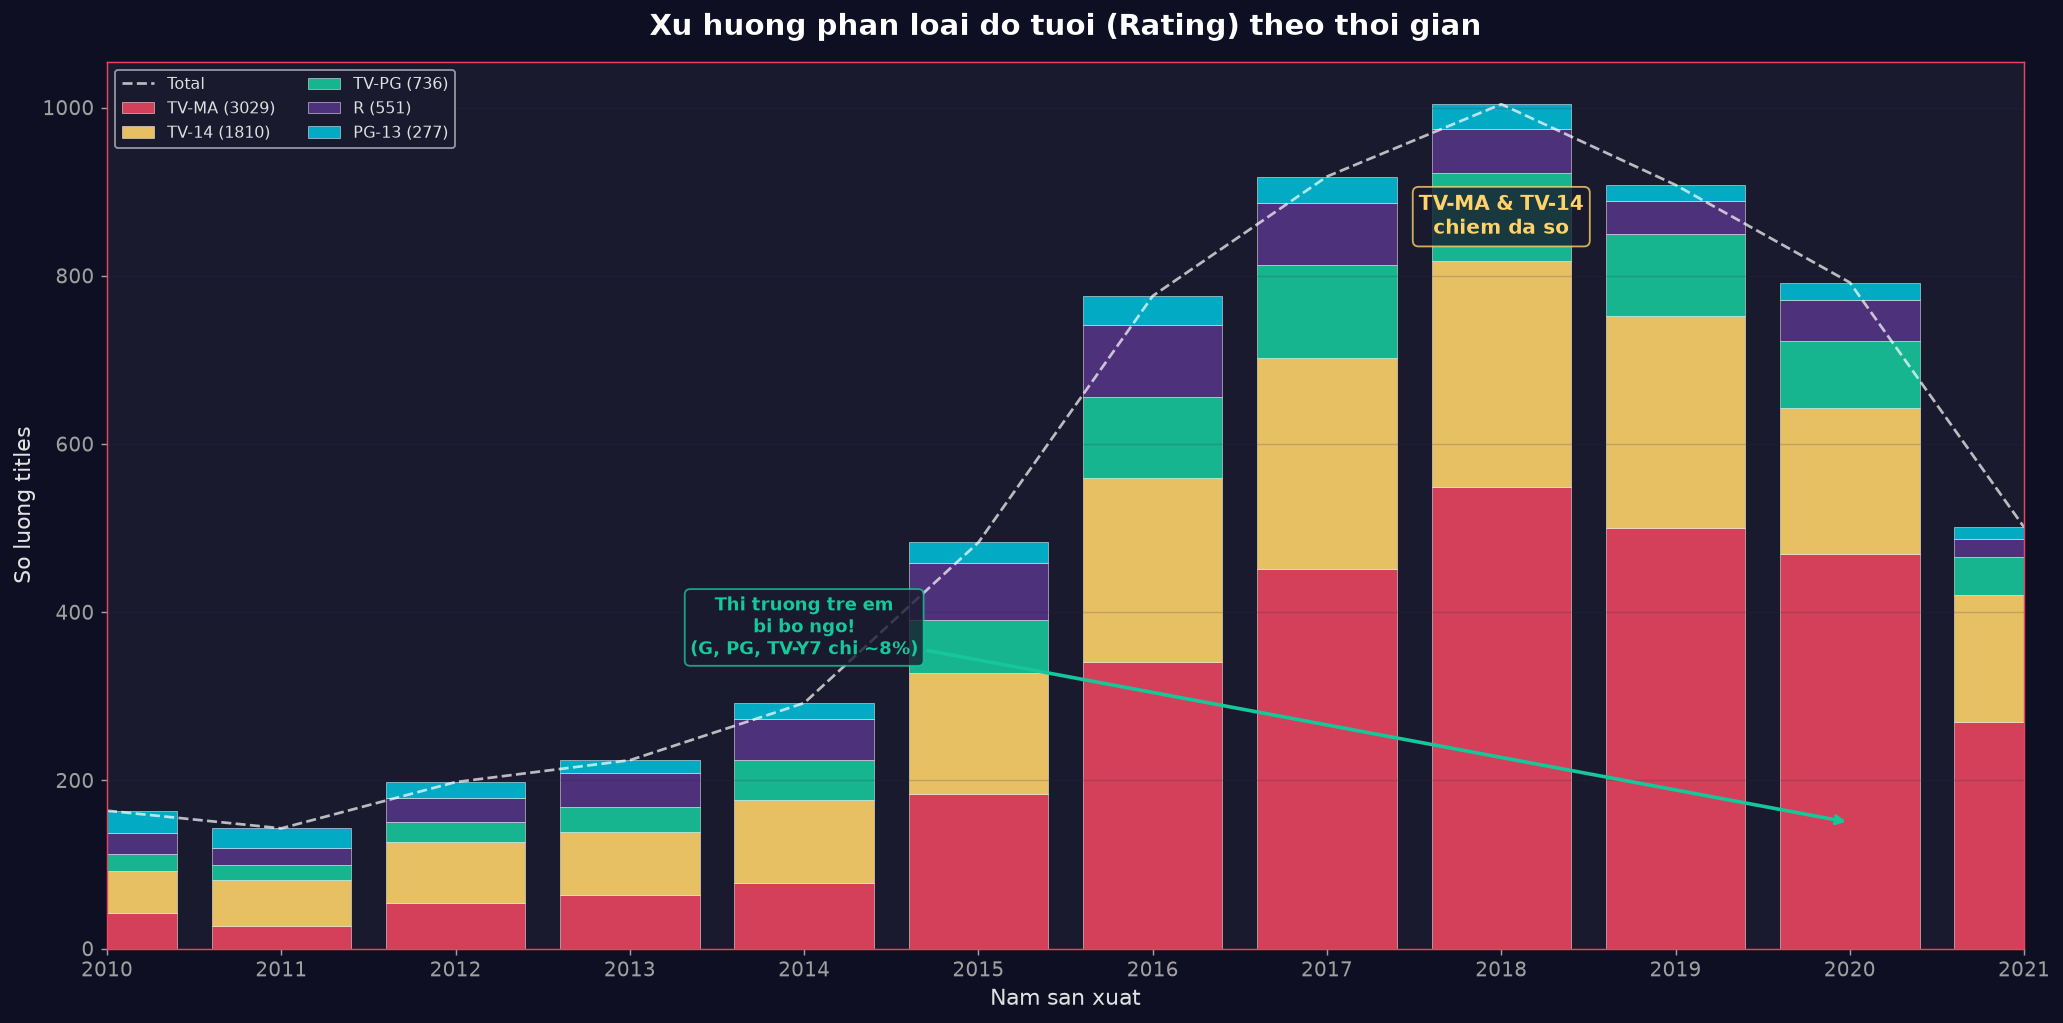

In [8]:
fig, ax = plt.subplots(figsize=(16, 8))
major_ratings = ['TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13']
rating_colors = {'TV-MA': ACCENT, 'TV-14': GOLD, 'TV-PG': GREEN, 'R': PURPLE, 'PG-13': CYAN}

rating_yearly = df.groupby(['release_year', 'rating']).size().unstack(fill_value=0)
rating_yearly = rating_yearly[rating_yearly.index >= 2010]
years = rating_yearly.index

bottom = np.zeros(len(years))
for rt in major_ratings:
    if rt in rating_yearly.columns:
        vals = rating_yearly[rt].values
        ax.bar(years, vals, bottom=bottom, label=f'{rt} ({int(vals.sum())})',
               color=rating_colors[rt], edgecolor='white', linewidth=0.3, alpha=0.9)
        bottom += vals

total_vals = rating_yearly[[c for c in major_ratings if c in rating_yearly.columns]].sum(axis=1)
ax.plot(years, total_vals, color='white', linewidth=1.5, linestyle='--', label='Total', alpha=0.7)

ax.annotate('TV-MA & TV-14\nchiem da so', xy=(2018, 850),
           fontsize=11, color=GOLD, fontweight='bold', ha='center',
           bbox=dict(boxstyle='round', facecolor=BG2, edgecolor=GOLD, alpha=0.8))

ax.annotate('Thi truong tre em\nbi bo ngo!\n(G, PG, TV-Y7 chi ~8%)',
           xy=(2020, 150), xytext=(2014, 350),
           fontsize=10, color=GREEN, fontweight='bold', ha='center',
           arrowprops=dict(arrowstyle='->', color=GREEN, lw=2),
           bbox=dict(boxstyle='round', facecolor=BG2, edgecolor=GREEN, alpha=0.8))

ax.set_xlabel('Nam san xuat', fontsize=12)
ax.set_ylabel('So luong titles', fontsize=12)
ax.set_title('Xu huong phan loai do tuoi (Rating) theo thoi gian', fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=9, loc='upper left', framealpha=0.7, facecolor=BG2, ncol=2)
ax.set_xlim(2010, 2021)
ax.set_xticks(range(2010, 2022))
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()



### 🔍 Phân tích chiến lược:

**Phân phối rating (Top 5):**

| Rating | Đối tượng | Số lượng | % |
|--------|-----------|---------|---|
| 🔞 **TV-MA** | 18+ (người lớn) | 3,206 | **36.4%** |
| 🟡 **TV-14** | ≥ 14 tuổi | 2,160 | **24.5%** |
| 🟢 **TV-PG** | Có bố mẹ | 863 | 9.8% |
| 🔴 **R** | 17+ (kèm người lớn) | 799 | 9.1% |
| 🔵 **PG-13** | ≥ 13 tuổi | 490 | 5.6% |

**🎯 Chiến thuật cho đối thủ:**
1. **60.9% nội dung Netflix là TV-MA + TV-14** {DASH} họ bỏ qua khán giả trẻ em và gia đình
2. **Nội dung trẻ em (G, PG, TV-Y, TV-Y7) chỉ chiếm ~8%** {DASH} Đây là **cơ hội VÀNG** cho Disney+, HBO Kids!
3. Rating G (41 titles) và TV-Y (307 titles) là những mảng Netflix gần như không đầu tư

---
## 🎬 CHART 4: THỂ LOẠI NỘI DUNG PHỔ BIẾN

**Mục tiêu:** Xác định Netflix mạnh thể loại nào và yếu thể loại nào.

**Góc nhìn đối thủ:** Tìm "khoảng trống" thể loại để tấn công.

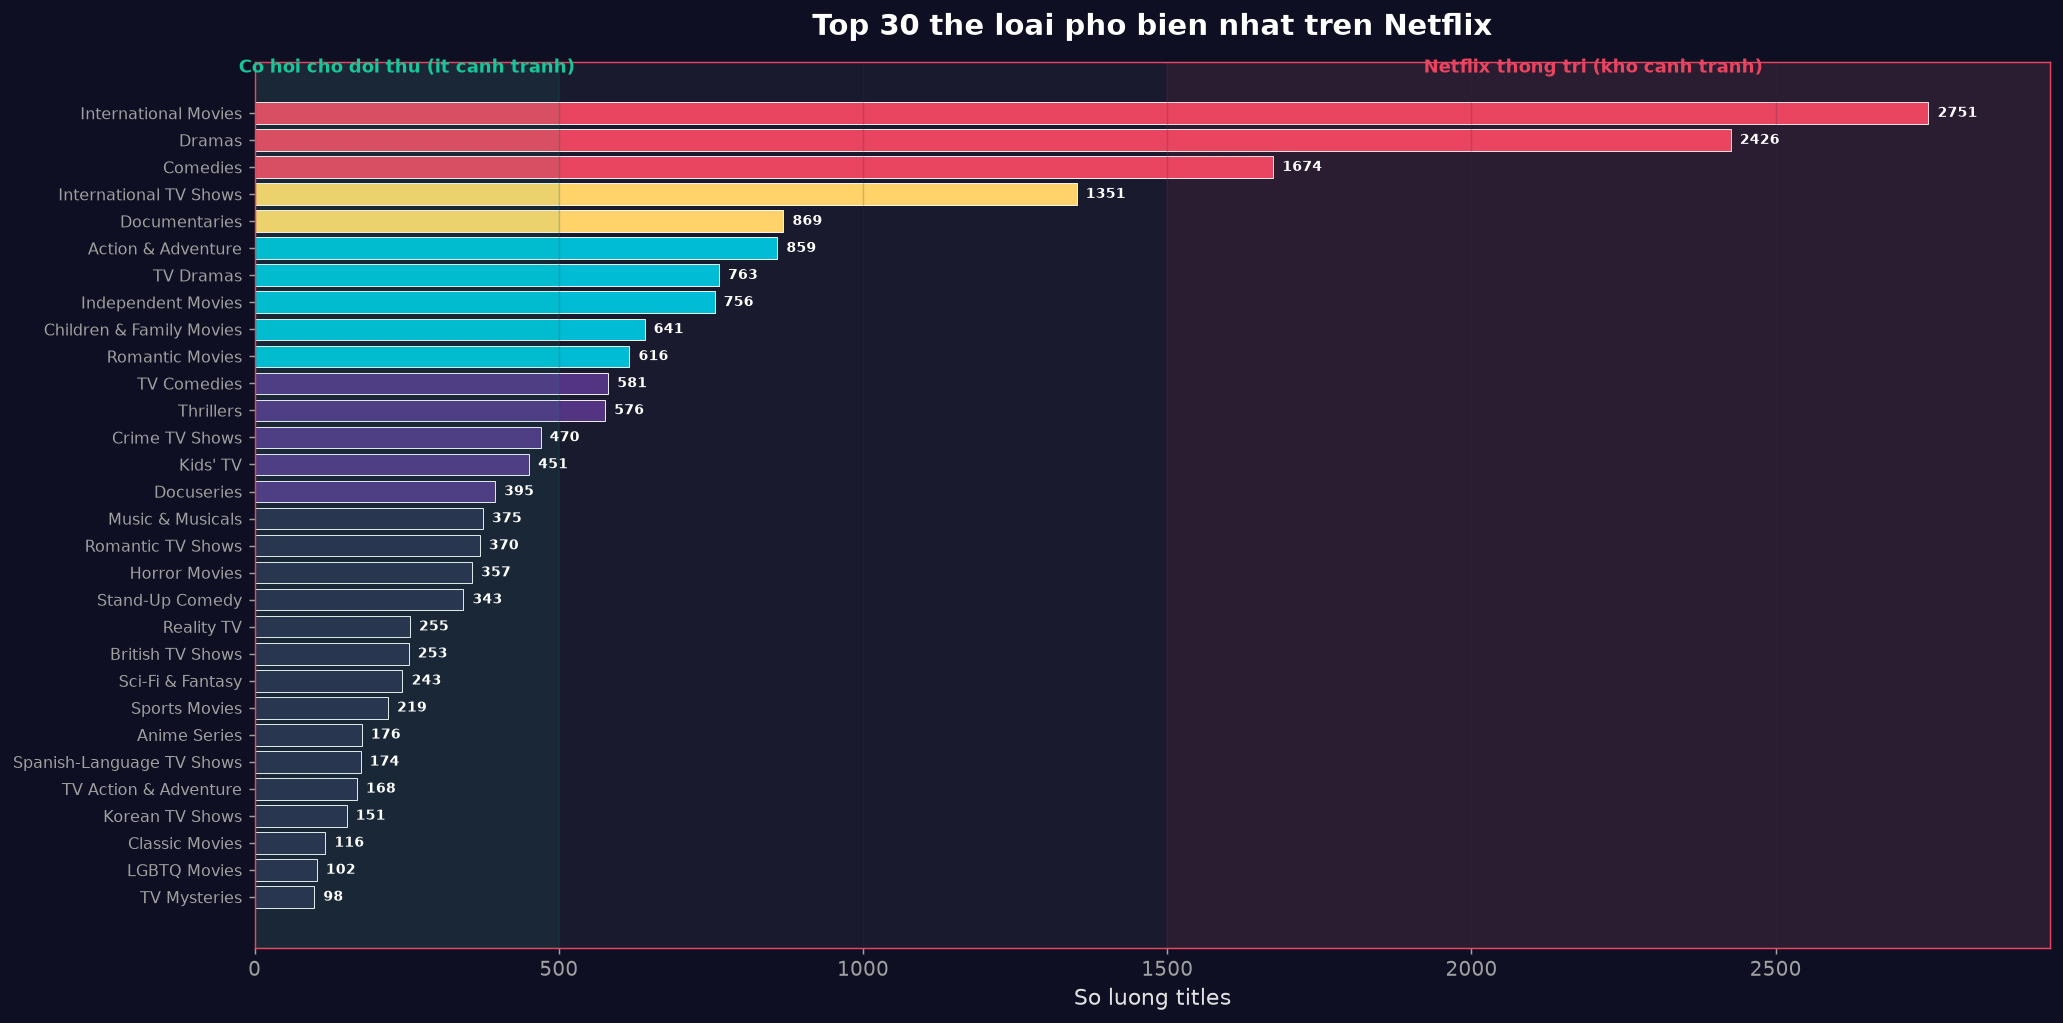

In [5]:
fig, ax = plt.subplots(figsize=(16, 8))
all_genres = []
for g in df['genres']:
    all_genres.extend(g)
genre_counts = Counter(all_genres)
top30 = dict(genre_counts.most_common(30))

genres = list(top30.keys())
counts = list(top30.values())
n_bars = len(counts)

bar_colors = []
for i in range(n_bars):
    if i < 3:
        bar_colors.append(ACCENT)
    elif i < 5:
        bar_colors.append(GOLD)
    elif i < 10:
        bar_colors.append(CYAN)
    elif i < 15:
        bar_colors.append(PURPLE)
    else:
        bar_colors.append('#2a2a4a')

bars = ax.barh(range(len(genres)), counts, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(genres)))
ax.set_yticklabels([f'{g}' for g in genres], fontsize=9)
ax.invert_yaxis()

for bar, v in zip(bars, counts):
    ax.text(v + 15, bar.get_y() + bar.get_height()/2, f'{v}',
           va='center', fontsize=8, fontweight='bold', color='white')

ax.axvspan(0, 500, alpha=0.08, color=GREEN)
ax.text(250, -1.5, 'Co hoi cho doi thu (it canh tranh)',
       fontsize=10, color=GREEN, fontweight='bold', ha='center')
ax.axvspan(1500, 3000, alpha=0.08, color=ACCENT)
ax.text(2200, -1.5, 'Netflix thong tri (kho canh tranh)',
       fontsize=10, color=ACCENT, fontweight='bold', ha='center')

ax.set_xlabel('So luong titles', fontsize=12)
ax.set_title('Top 30 the loai pho bien nhat tren Netflix', fontsize=16, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.2)
ax.set_xlim(0, max(counts) + 200)
plt.tight_layout()
plt.show()



### 🔍 Phân tích chiến lược:

**5 thể loại mạnh nhất của Netflix:**
1. 🌍 **International Movies** — 2,751 (31.2%)
2. **Dramas** {DASH} 2,426 (27.5%)
3. **Comedies** {DASH} 1,674 (19.0%)
4. **International TV Shows** {DASH} 1,351 (15.3%)
5. **Documentaries** {DASH} 869 (9.9%)

**🟢 Cơ hội cho đối thủ (thể loại Netflix yếu):**

| Thể loại | Số lượng | % | Chiến lược |
|---------|---------|---|-----------|
| 🏃 **Sports Movies** | ~30 | 0.3% | **Mảng trống!** |
| 🎪 **Reality TV** | 255 | 2.9% | Netflix yếu |
| 👨‍👩‍👧‍👦 **Children & Family** | 641 | 7.3% | Disney+ đã làm tốt |
| 🎤 **Stand-Up Comedy** | 343 | 3.9% | Thị trường ngách |
| 🎵 **Music & Musicals** | 375 | 4.3% | Có thể phát triển thêm |

---
## 🌍 CHART 5: PHÂN TÍCH QUỐC GIA — Thị trường & Cơ hội mở rộng

**Mục tiêu:** Xác định Netflix phụ thuộc vào thị trường nào và đâu là thị trường tiềm năng bị bỏ ngỏ.

**Góc nhìn đối thủ:** Mở rộng vào thị trường Netflix chưa khai thác tốt.

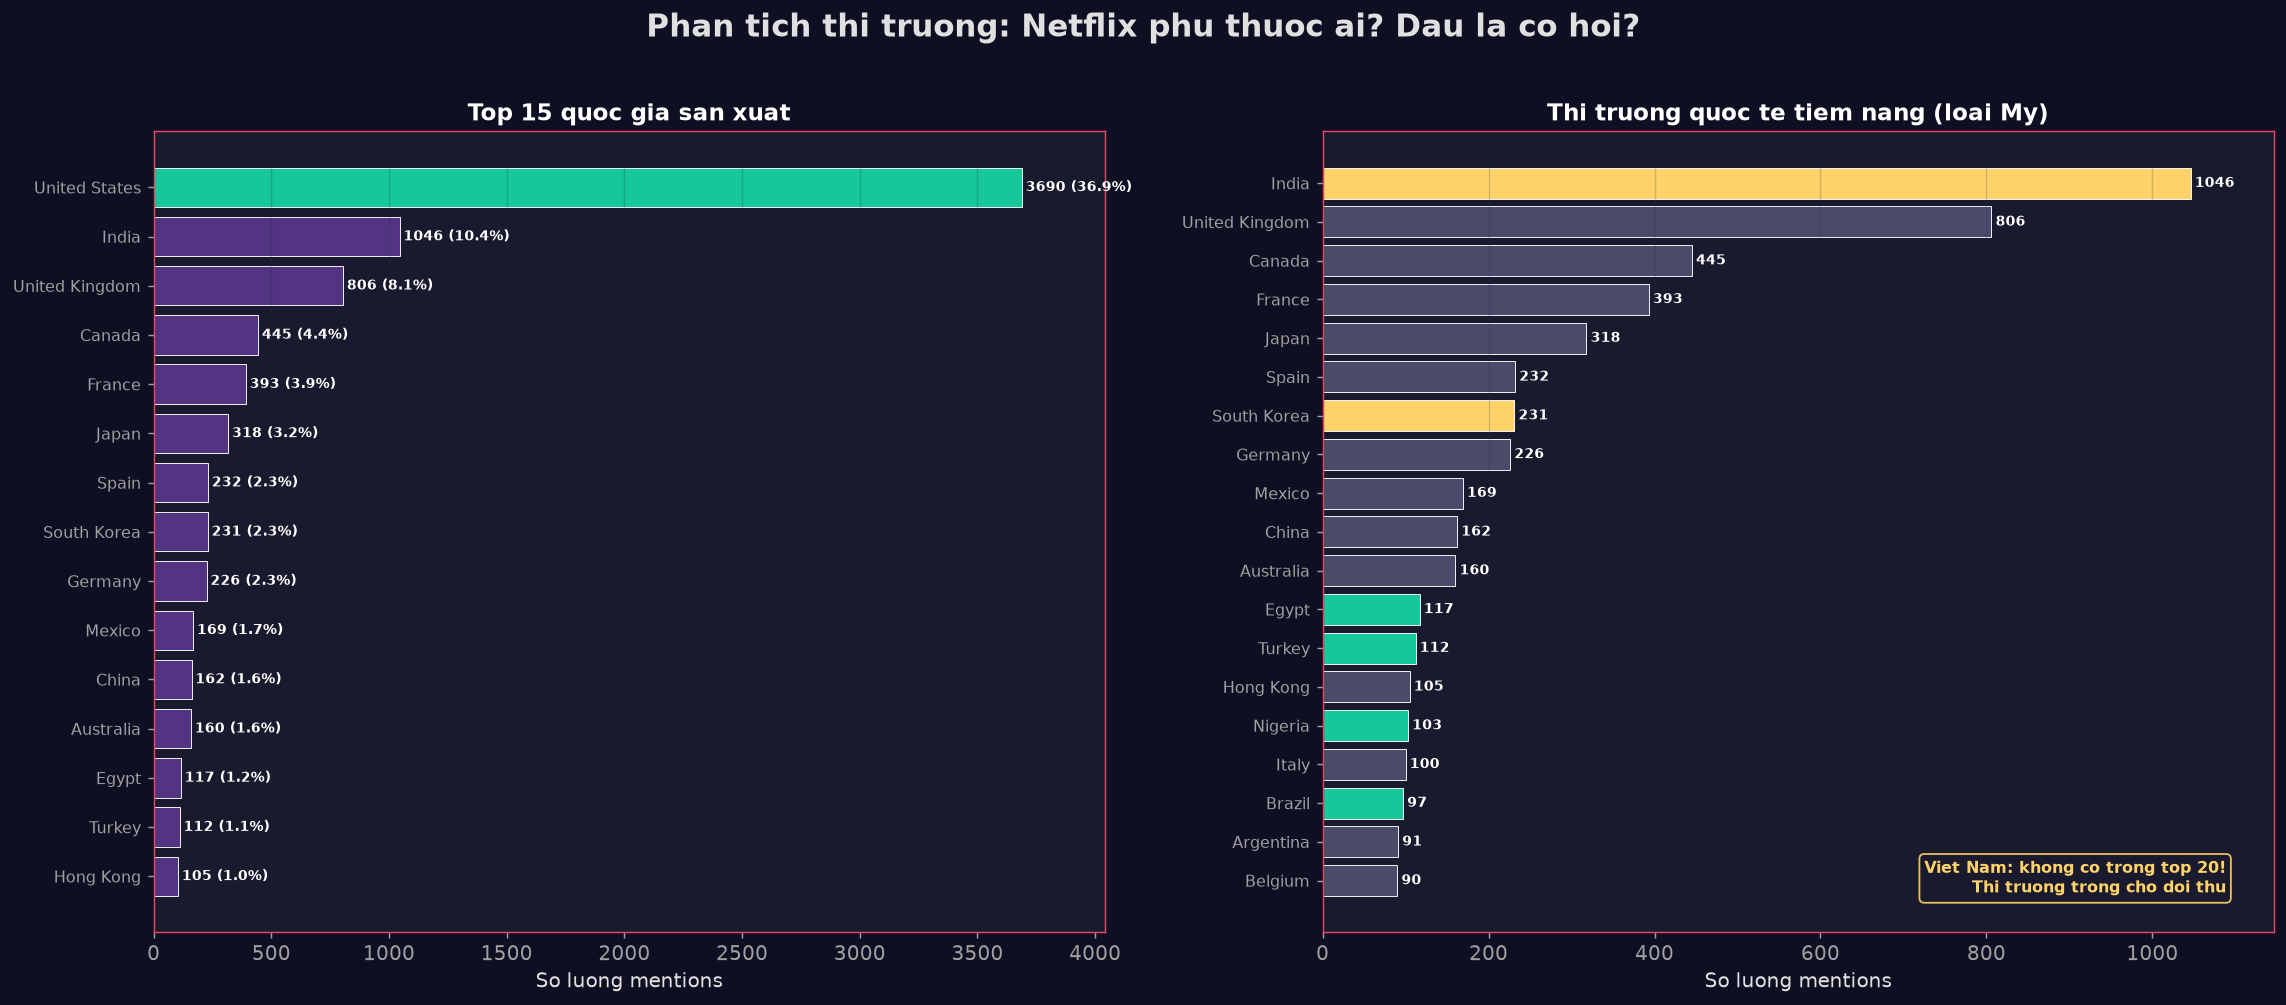

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Phan tich thi truong: Netflix phu thuoc ai? Dau la co hoi?',
            fontsize=17, fontweight='bold', y=0.98)

all_countries = []
for c in df['countries']:
    all_countries.extend(c)
country_counts = Counter(all_countries)

# LEFT: Top 15
ax1 = axes[0]
top15 = dict(country_counts.most_common(15))
countries = list(top15.keys())
counts_c = list(top15.values())
c_colors = [GREEN if c == 'United States' else PURPLE for c in countries]

bars1 = ax1.barh(range(len(countries)), counts_c, color=c_colors, edgecolor='white', linewidth=0.5)
ax1.set_yticks(range(len(countries)))
ax1.set_yticklabels(countries, fontsize=9)
ax1.invert_yaxis()

total_mentions = sum(country_counts.values())
for bar, v in zip(bars1, counts_c):
    pct = v/total_mentions*100
    ax1.text(v + 15, bar.get_y() + bar.get_height()/2, f'{v} ({pct:.1f}%)',
           va='center', fontsize=8, fontweight='bold', color='white')

ax1.set_xlabel('So luong mentions')
ax1.set_title('Top 15 quoc gia san xuat', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.2)
ax1.set_xlim(0, max(counts_c) + 350)

# RIGHT: Non-US
ax2 = axes[1]
non_us = {g: c for g, c in country_counts.most_common(20) if g != 'United States'}
countries_nu = list(non_us.keys())
counts_nu = list(non_us.values())

potentials = ['India', 'South Korea', 'Nigeria', 'Turkey', 'Brazil', 'Egypt']
colors_nu = []
for c in countries_nu:
    if c in potentials:
        colors_nu.append(GREEN if c in ['India', 'South Korea'] else GOLD)
    else:
        colors_nu.append(GRAY)

bars2 = ax2.barh(range(len(countries_nu)), counts_nu, color=colors_nu, edgecolor='white', linewidth=0.5)
ax2.set_yticks(range(len(countries_nu)))
ax2.set_yticklabels(countries_nu, fontsize=9)
ax2.invert_yaxis()

for bar, v in zip(bars2, counts_nu):
    ax2.text(v + 5, bar.get_y() + bar.get_height()/2, f'{v}',
           va='center', fontsize=8, fontweight='bold', color='white')

ax2.set_xlabel('So luong mentions')
ax2.set_title('Thi truong quoc te tiem nang (loai My)', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.2)
ax2.set_xlim(0, max(counts_nu) + 100)

# Vietnam text box
ax2.text(0.95, 0.05, 'Viet Nam: khong co trong top 20!\nThi truong trong cho doi thu',
        transform=ax2.transAxes, ha='right', fontsize=9, color=GOLD, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor=BG2, edgecolor=GOLD, alpha=0.9))

plt.tight_layout(pad=2)
plt.show()



### 🔍 Phân tích chiến lược:

**Phụ thuộc vào Mỹ:**
- 🇺🇸 **Mỹ: 3,690 titles (42%)** — Netflix phụ thuộc quá nhiều vào nội dung Mỹ
- 🇮🇳 **Ấn Độ: 1,046 (11.9%)** — Thị trường số 2, Netflix đã đầu tư mạnh
- 🇬🇧 **Anh: 806 (9.2%)** — Đối tác châu Âu lớn nhất

**Cơ hội mở rộng cho đối thủ:**

| Thị trường | Số titles Netflix | Chiến lược đối thủ |
|-----------|-----------------|-------------------|
| 🇰🇷 **Hàn Quốc** | 231 | Đầu tư K-drama |
| 🇹🇷 **Thổ Nhĩ Kỳ** | 112 | Phim Thổ đang lên |
| 🇳🇬 **Nigeria** | 103 | Nollywood bùng nổ |
| 🇧🇷 **Brazil** | 97 | Telenovela lượng fan lớn |
| 🇻🇳 **Việt Nam** | **?** | **Thị trường gần như trống!** |

---
## 📅 CHART 6: THỜI ĐIỂM PHÁT HÀNH — Chiến lược theo mùa

**Mục tiêu:** Hiểu Netflix phát hành nội dung vào thời điểm nào trong năm.

**Góc nhìn đối thủ:** Tấn công vào thời điểm Netflix yếu hoặc đón đầu mùa cao điểm.

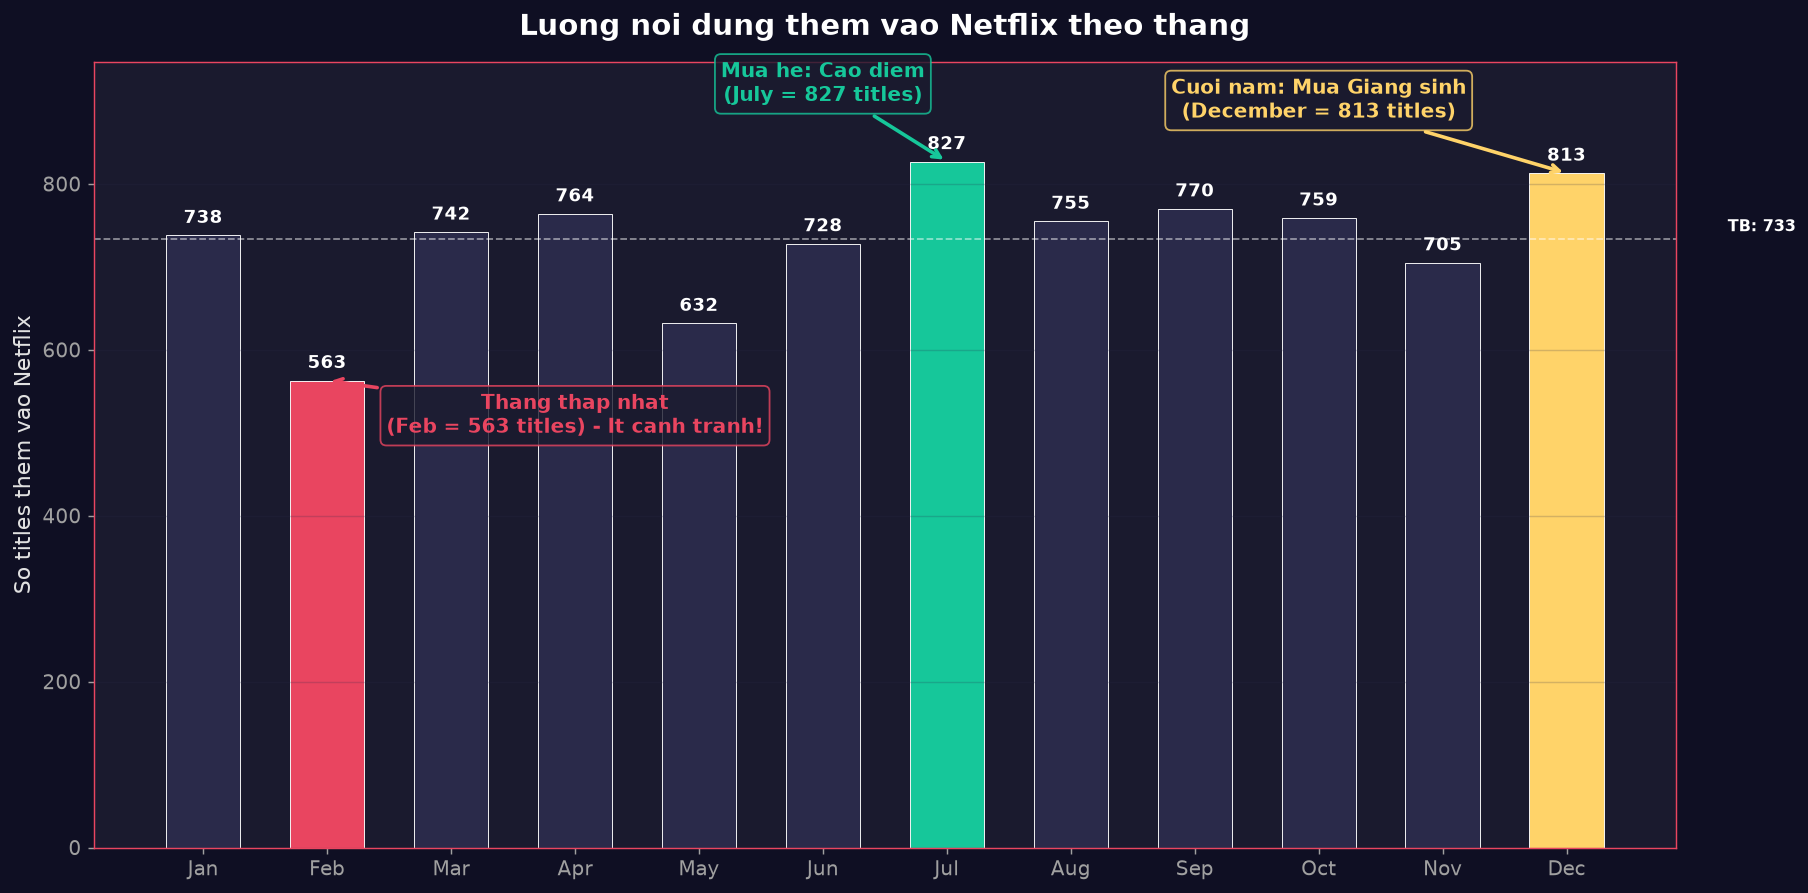

In [15]:
fig, ax = plt.subplots(figsize=(14, 7))
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

month_counts = df['added_month'].value_counts().reindex(range(1, 13)).fillna(0).astype(int)

colors_bar = []
for m in range(1, 13):
    if m == 7:
        colors_bar.append(GREEN)
    elif m == 12:
        colors_bar.append(GOLD)
    elif m == 2:
        colors_bar.append(ACCENT)
    else:
        colors_bar.append('#2a2a4a')

bars = ax.bar(month_names, month_counts.values, color=colors_bar,
             edgecolor='white', linewidth=0.5, width=0.6)

for bar, v in zip(bars, month_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15, str(v),
           ha='center', fontsize=10, fontweight='bold', color='white')

ax.annotate('Mua he: Cao diem\n(July = 827 titles)',
           xy=(6, 827), xytext=(5, 900),
           fontsize=11, color=GREEN, fontweight='bold', ha='center',
           arrowprops=dict(arrowstyle='->', color=GREEN, lw=2),
           bbox=dict(boxstyle='round', facecolor=BG2, edgecolor=GREEN, alpha=0.8))

ax.annotate('Cuoi nam: Mua Giang sinh\n(December = 813 titles)',
           xy=(11, 813), xytext=(9, 880),
           fontsize=11, color=GOLD, fontweight='bold', ha='center',
           arrowprops=dict(arrowstyle='->', color=GOLD, lw=2),
           bbox=dict(boxstyle='round', facecolor=BG2, edgecolor=GOLD, alpha=0.8))

ax.annotate('Thang thap nhat\n(Feb = 563 titles) - It canh tranh!',
           xy=(1, 563), xytext=(3, 500),
           fontsize=11, color=ACCENT, fontweight='bold', ha='center',
           arrowprops=dict(arrowstyle='->', color=ACCENT, lw=2),
           bbox=dict(boxstyle='round', facecolor=BG2, edgecolor=ACCENT, alpha=0.8))

avg_month = month_counts.mean()
ax.axhline(y=avg_month, color='white', linewidth=1, linestyle='--', alpha=0.5)
ax.text(12.3, avg_month + 10, f'TB: {avg_month:.0f}', fontsize=9, color='white', fontweight='bold')

ax.set_ylabel('So titles them vao Netflix', fontsize=12)
ax.set_title('Luong noi dung them vao Netflix theo thang', fontsize=16, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.2)
ax.set_ylim(0, max(month_counts.values) + 120)
plt.tight_layout()
plt.show()



### 🔍 Phân tích chiến lược:

**Mùa cao điểm:**
- **Tháng 7 (827)** — Mùa hè, người dùng rảnh xem phim
- **Tháng 12 (813)** — Giáng sinh, nghỉ lễ cuối năm

**Mùa thấp điểm:**
- **Tháng 2 (563)** {DASH} Thấp nhất năm

**🎯 Chiến thuật cho đối thủ:**
1. **Tấn công vào tháng 2** {DASH} Netflix yếu nhất, ít cạnh tranh
2. **Đón đầu mùa hè (Tháng 5-6)** {DASH} Ra mắt nội dung mới TRƯỚC Netflix
3. **Tháng 12 là cuộc chiến Giáng sinh** {DASH} Disney+ đã tận dụng rất tốt

---
<div style='background: linear-gradient(135deg, #0f0f23, #1a1a2e); padding: 25px; border-radius: 15px; border: 2px solid #e94560;'>
<h2 style='color: #ffffff; text-align: center;'>🎯 TỔNG KẾT CHIẾN LƯỢC</h2>

<p style='color: #e0e0e0; font-size: 14px; line-height: 1.6;'>
<b style='color: #e94560;'>🔴 ĐIỂM YẾU CỦA NETFLIX (Cơ hội cho đối thủ):</b><br>
1. <b>Phụ thuộc Movie (70%)</b> {DASH} TV Show đang lên<br>
2. <b>Bỏ ngỏ thị trường trẻ em & gia đình</b> {DASH} Chỉ ~8%<br>
3. 🇺🇸 <b>Phụ thuộc Mỹ (42%)</b> — Chưa khai thác hết quốc tế<br>
4. 🏃 <b>Thiếu: Sports, Reality, Music</b> — Cơ hội cho đối thủ<br>
5. <b>Chiến lược phát hành dễ đoán</b><br>
</p>

<p style='color: #e0e0e0; font-size: 14px; line-height: 1.6;'>
<b style='color: #16c79a;'>🟢 CHIẾN THUẬT CHO ĐỐI THỦ:</b><br>
1. <b>Đầu tư vào nội dung gia đình</b> {DASH} Disney+ đã chứng minh<br>
2. 🌍 <b>Mở rộng thị trường châu Á</b> — Hàn Quốc, Việt Nam<br>
3. <b>TV Show là tương lai</b> {DASH} Tấn công vào đúng hướng<br>
4. <b>Thử nghiệm nội dung ngắn</b> {DASH} Netflix bỏ ngỏ phim <60 phút<br>
5. <b>Tấn công vào tháng 2</b> {DASH} Thời điểm Netflix yếu nhất
</p>
</div>

---
<p style='text-align: center; color: #666; font-size: 11px;'>
Phân tích từ bộ dữ liệu Netflix Titles (Kaggle) • 8,806 titles<br>
</p>